# 07 — Previsão de Rebaixamento 2025

Aplicação do modelo final (Regressão Logística treinada em 2014–2024) para prever os clubes com maior risco de rebaixamento na temporada 2025.

## Carregamento do Modelo Final Salvo

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import os

METRICAS = ['Pts', 'SG', 'Gols_Pro', 'Gols_Contra', 'V', 'Aproveitamento']
JANELAS  = [3, 5]
COLS_JANELA = [f'{m}_media_{w}' for m in METRICAS for w in JANELAS]
FEATURES_ELENCO = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
FEATURES = FEATURES_ELENCO + COLS_JANELA

modelo  = joblib.load(os.path.join('..','modelos','logistica.pkl'))
scaler  = joblib.load(os.path.join('..','modelos','scaler_logistica.pkl'))
print('Modelo carregado:', type(modelo).__name__)
print(f"Features esperadas: {len(FEATURES)}")

Modelo carregado: LogisticRegression
Features esperadas: 15


## Dados dos Clubes para 2025

In [2]:
# Carrega base principal
df = pd.read_excel(os.path.join('..','dados','BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()

# Carrega e processa desempenho histórico para construir janelas
df_desemp = pd.read_excel(os.path.join('..','dados','tabela_desempenho_brasileirao.xlsx'), sheet_name='Todos')
df_desemp.columns = df_desemp.columns.str.strip()
df_desemp = df_desemp.sort_values(['Clube', 'Temporada']).reset_index(drop=True)
for metrica in METRICAS:
    for w in JANELAS:
        df_desemp[f'{metrica}_media_{w}'] = (
            df_desemp.groupby('Clube')[metrica]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        )

# Extensão 2025
clubes_2025 = df['Clube'][df['Temporada'] == 2025].unique()
rows_2025 = []
for clube in clubes_2025:
    hist = df_desemp[df_desemp['Clube'] == clube].sort_values('Temporada', ascending=False)
    row  = {'Clube': clube, 'Temporada': 2025}
    for metrica in METRICAS:
        for w in JANELAS:
            ultimos = hist.head(w)[metrica]
            row[f'{metrica}_media_{w}'] = ultimos.mean() if len(ultimos) > 0 else None
    rows_2025.append(row)
COLS_MERGE = ['Clube', 'Temporada'] + COLS_JANELA
df_desemp_ext = pd.concat(
    [df_desemp[COLS_MERGE], pd.DataFrame(rows_2025)[COLS_MERGE]],
    ignore_index=True
)
df = df.merge(df_desemp_ext[COLS_MERGE], on=['Clube', 'Temporada'], how='left')

df_2025 = df[df['Temporada'] == 2025].copy()
# Preencher NaN com mediana do treino (mesmo que foi usado no treinamento)
df_treino = df[df['Temporada'] <= 2022].copy()
mediana_ref = df_treino[COLS_JANELA].median()
for col in COLS_JANELA:
    df_2025[col] = df_2025[col].fillna(mediana_ref[col])

print(f'Clubes para previsao: {len(df_2025)}')
df_2025[['Clube'] + FEATURES_ELENCO + COLS_JANELA[:3]]

Clubes para previsao: 20


,Clube,Plantel,Estrangeiros,Valor de Mercado Total,Pts_media_3,Pts_media_5,SG_media_3
220,Flamengo,74,12,273.50,66.000000,68.000000,18.000000
221,Palmeiras,54,11,260.35,74.666667,69.600000,32.333333
222,Botafogo,82,17,214.65,65.333333,53.200000,16.333333
223,Santos,52,12,150.00,46.666667,53.600000,-9.000000
224,Atletico Mineiro,67,7,127.75,57.000000,64.600000,7.000000
225,Gremio,58,13,124.68,52.000000,56.000000,-2.000000
226,Vasco da Gama,70,14,122.60,45.333333,45.600000,-14.000000
227,Cruzeiro,50,10,121.40,45.000000,49.000000,-4.666667
228,Corinthians,47,11,105.40,57.000000,55.800000,5.333333
229,Sao Paulo,55,12,99.20,55.333333,56.000000,8.333333


## Geração das Probabilidades de Rebaixamento

In [3]:
X_2025 = scaler.transform(df_2025[FEATURES])
probs  = modelo.predict_proba(X_2025)
idx_reb = list(modelo.classes_).index(1)

df_prev = df_2025[['Clube'] + FEATURES].copy()
df_prev['Prob_Rebaixamento(%)']  = (probs[:, idx_reb] * 100).round(2)
df_prev['Prob_Permanencia(%)']   = (probs[:, 1-idx_reb] * 100).round(2)
df_prev['Previsao']              = np.where(df_prev['Prob_Rebaixamento(%)'] >= 50, 'Rebaixado', 'Permanece')

df_prev = df_prev.sort_values('Prob_Rebaixamento(%)', ascending=False).reset_index(drop=True)
df_prev.index += 1

# Marca os 4 primeiros como rebaixados (independente do limiar)
df_prev.loc[df_prev.index <= 4, 'Previsao'] = 'Rebaixado'

print('Tabela de Previsao 2025:')
df_prev[['Clube','Prob_Rebaixamento(%)','Prob_Permanencia(%)','Previsao']]

Tabela de Previsao 2025:


,Clube,Prob_Rebaixamento(%),Prob_Permanencia(%),Previsao
1,Juventude,79.37,20.63,Rebaixado
2,Sport Recife,76.88,23.12,Rebaixado
3,Vitoria,76.72,23.28,Rebaixado
4,Mirassol,43.63,56.37,Rebaixado
5,Ceara,35.26,64.74,Permanece
6,Bahia,33.09,66.91,Permanece
7,Fortaleza,27.94,72.06,Permanece
8,Fluminense,25.82,74.18,Permanece
9,Vasco da Gama,24.07,75.93,Permanece
10,Bragantino,13.08,86.92,Permanece


## Gráfico de Barras Horizontal — Ranking de Risco

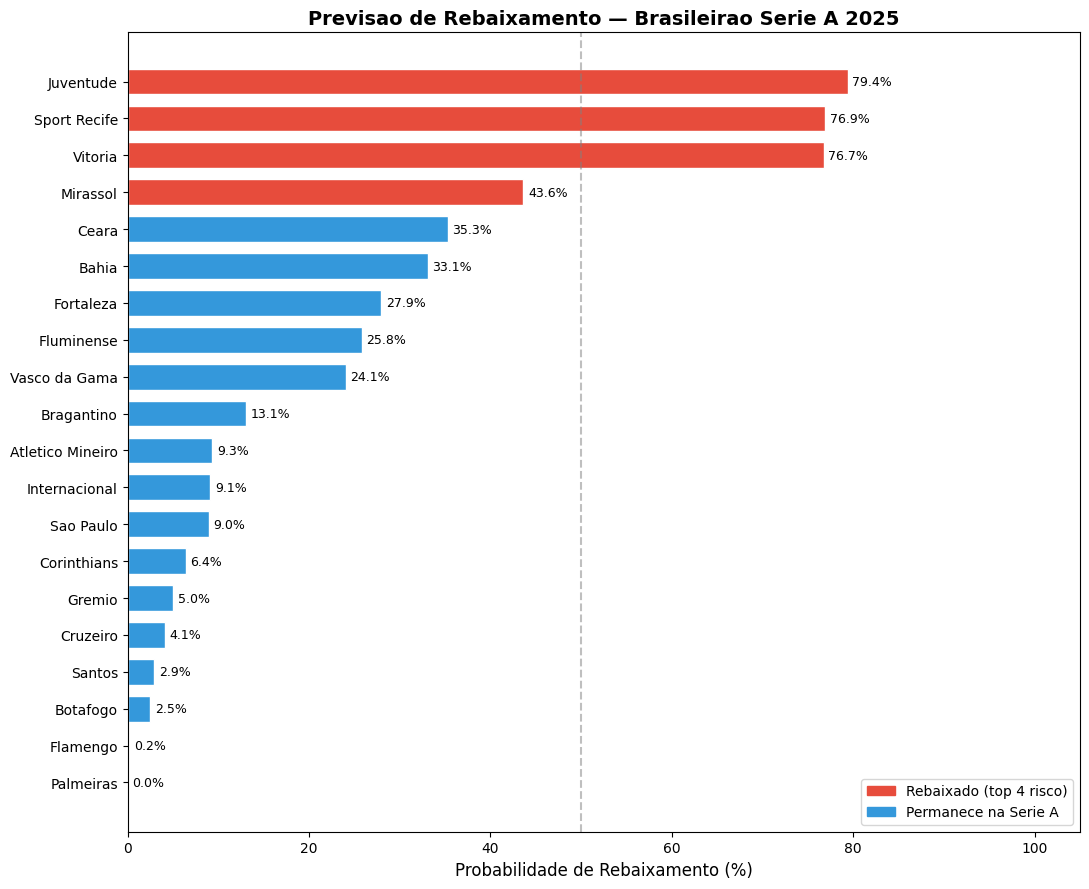

In [4]:
fig, ax = plt.subplots(figsize=(11, 9))

cores_bar = ['#e74c3c' if p=='Rebaixado' else '#3498db' for p in df_prev['Previsao']]
bars = ax.barh(
    df_prev['Clube'][::-1],
    df_prev['Prob_Rebaixamento(%)'][::-1],
    color=cores_bar[::-1], edgecolor='white', height=0.7
)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='Limiar 50%')
ax.set_xlabel('Probabilidade de Rebaixamento (%)', fontsize=12)
ax.set_title(f'Previsao de Rebaixamento — Brasileirao Serie A 2025', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)
for bar, val in zip(bars, df_prev['Prob_Rebaixamento(%)'][::-1]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Rebaixado (top 4 risco)'),
    mpatches.Patch(color='#3498db', label='Permanece na Serie A')
], loc='lower right')
plt.tight_layout()
os.makedirs(os.path.join('..','img'), exist_ok=True)
plt.savefig(os.path.join('..','img','previsao_2025.png'), dpi=150, bbox_inches='tight')
plt.show()

## Tabela Final de Resultados

In [5]:
print('=' * 70)
print('  PREVISAO DE REBAIXAMENTO — BRASILEIRAO SERIE A 2025')
print('=' * 70)
print(f'  Modelo: Regressao Logistica | Treinado em: 2014-2024')
print('=' * 70)
for _, row in df_prev.iterrows():
    status = '*** REBAIXADO ***' if row['Previsao']=='Rebaixado' else 'Permanece'
    print(f"  {row.name:>2}. {row['Clube']:<25} {row['Prob_Rebaixamento(%)']:>6.1f}%  {status}")
print('=' * 70)

  PREVISAO DE REBAIXAMENTO — BRASILEIRAO SERIE A 2025
  Modelo: Regressao Logistica | Treinado em: 2014-2024
   1. Juventude                   79.4%  *** REBAIXADO ***
   2. Sport Recife                76.9%  *** REBAIXADO ***
   3. Vitoria                     76.7%  *** REBAIXADO ***
   4. Mirassol                    43.6%  *** REBAIXADO ***
   5. Ceara                       35.3%  Permanece
   6. Bahia                       33.1%  Permanece
   7. Fortaleza                   27.9%  Permanece
   8. Fluminense                  25.8%  Permanece
   9. Vasco da Gama               24.1%  Permanece
  10. Bragantino                  13.1%  Permanece
  11. Atletico Mineiro             9.3%  Permanece
  12. Internacional                9.1%  Permanece
  13. Sao Paulo                    9.0%  Permanece
  14. Corinthians                  6.4%  Permanece
  15. Gremio                       5.0%  Permanece
  16. Cruzeiro                     4.1%  Permanece
  17. Santos                       2.9%  Pe

## Análise dos Resultados

**Clubes em zona de risco (4 primeiros):** são os que o modelo aponta como maior probabilidade de rebaixamento com base nas features de 2025 (tamanho do elenco, estrangeiros e valor de mercado).

**Limitações desta previsão:**
1. Dados de 2025 podem não refletir mudanças de elenco ao longo da temporada
2. O modelo não captura fatores externos (lesões, mudança técnica, calendário sobrecarregado)
3. A variável `Pontos` não está disponível antes do fim da temporada
4. Desempenho dentro de campo tem peso que as variáveis financeiras não capturam completamente

**Trabalhos futuros:**
- Incluir features de desempenho em campo (aproveitamento, saldo de gols)
- Aplicar modelos de séries temporais (LSTM, Prophet)
- Retreinar o modelo ao longo da temporada com dados parciais de pontuação